In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

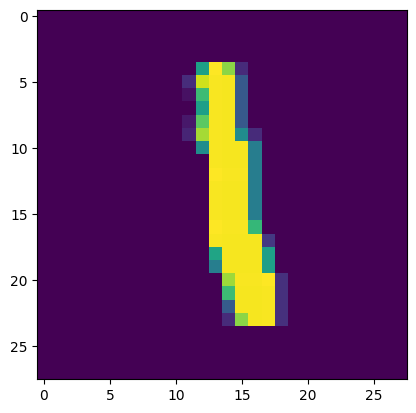

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X_train[6])

In [5]:
X_train=X_train/255
X_test=X_test/255

In [15]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam')

In [31]:
history=model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0056 - val_loss: 0.1401
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0069 - val_loss: 0.1638
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0116 - val_loss: 0.1645
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0060 - val_loss: 0.1492
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0078 - val_loss: 0.1477
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0077 - val_loss: 0.1961
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0062 - val_loss: 0.1730
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0076 - val_loss: 0.1639
Epoch 9/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0071 - val_loss: 0.1792
Epoch 10/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0061 - val_loss: 0.1761
Epoch 11/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0076 - val_loss: 0.1788
Epoch 12/25
1500/1500 ━━━━━━━

In [32]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [33]:
y_prob

array([[1.7418364e-21, 1.1601412e-20, 2.4258027e-21, ..., 9.9999994e-01,
        2.1302042e-15, 1.9012217e-10],
       [8.5711493e-25, 2.2627714e-13, 9.9999994e-01, ..., 5.1226637e-30,
        1.0959541e-22, 2.4509847e-34],
       [2.3980774e-24, 9.9999994e-01, 8.3670533e-15, ..., 2.2941924e-12,
        1.0912005e-11, 9.9174381e-18],
       ...,
       [5.4621431e-38, 1.2129337e-24, 8.4871666e-34, ..., 6.7870407e-17,
        1.1722223e-22, 1.9203798e-15],
       [0.0000000e+00, 0.0000000e+00, 2.9537855e-38, ..., 1.3860160e-33,
        2.8732710e-21, 0.0000000e+00],
       [4.3470704e-21, 2.6243886e-29, 9.7465250e-26, ..., 2.5778874e-33,
        3.9037350e-24, 6.5220330e-24]], dtype=float32)

In [34]:
y_pred=y_prob.argmax(axis=1)

In [35]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9752

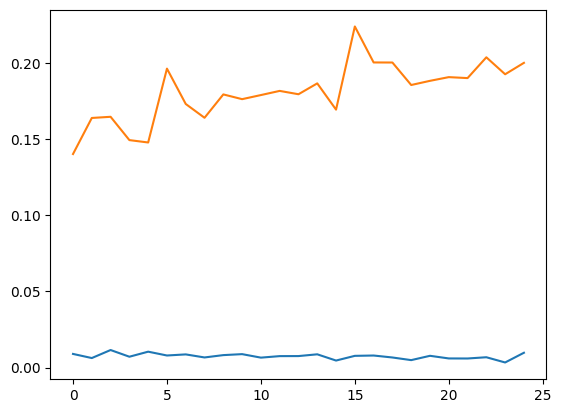

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

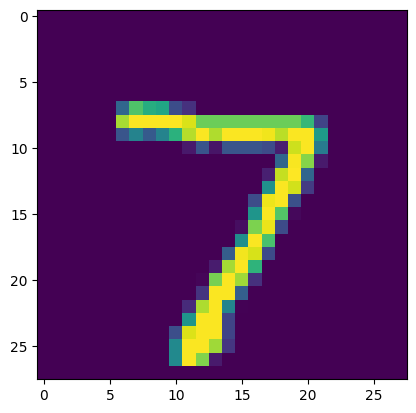

In [39]:
plt.imshow(X_test[0])

In [40]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([7])

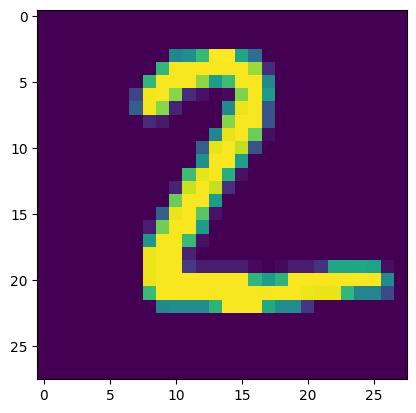

In [41]:
plt.imshow(X_test[1])

In [42]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


array([2])